In [ ]:
from PIL import Image

In [ ]:
image=Image.open("/content/1367741.jpeg")

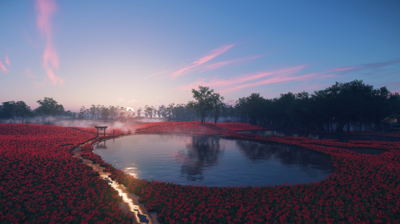

In [ ]:
image_resized=image=image.resize((400,224))
image


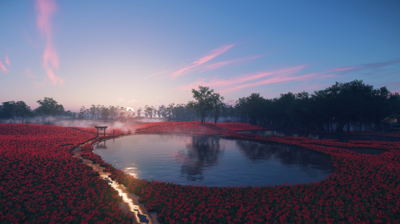

In [ ]:
image_resized

In [ ]:
import numpy as np
image_array=np.array(image)/255.0
image_array

array([[[0.30588235, 0.49019608, 0.70196078],
        [0.30980392, 0.49019608, 0.70588235],
        [0.31372549, 0.49411765, 0.70588235],
        ...,
        [0.16078431, 0.31764706, 0.50980392],
        [0.16078431, 0.31764706, 0.50980392],
        [0.16078431, 0.31764706, 0.50980392]],

       [[0.31372549, 0.49019608, 0.70588235],
        [0.31764706, 0.49411765, 0.70980392],
        [0.31764706, 0.49411765, 0.70980392],
        ...,
        [0.16470588, 0.32156863, 0.51372549],
        [0.16470588, 0.32156863, 0.51372549],
        [0.16470588, 0.32156863, 0.51372549]],

       [[0.32156863, 0.49803922, 0.71372549],
        [0.32156863, 0.49803922, 0.71372549],
        [0.3254902 , 0.50196078, 0.71764706],
        ...,
        [0.16862745, 0.3254902 , 0.51764706],
        [0.16862745, 0.32156863, 0.51372549],
        [0.16470588, 0.32156863, 0.51372549]],

       ...,

       [[0.05882353, 0.09803922, 0.11372549],
        [0.06666667, 0.10980392, 0.1254902 ],
        [0.07058824, 0

array([[136, 136, 137, ...,  91,  91,  91],
       [136, 137, 137, ...,  92,  92,  92],
       [138, 138, 139, ...,  93,  92,  92],
       ...,
       [ 25,  28,  27, ...,  29,  25,  25],
       [ 24,  24,  27, ...,  29,  25,  21],
       [ 29,  27,  31, ...,  29,  25,  29]], dtype=uint8)
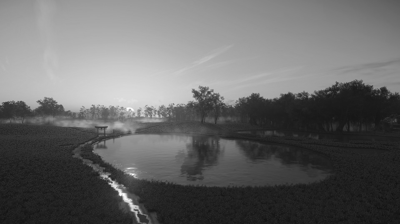

In [ ]:
from cv2 import cvtColor,COLOR_BGR2GRAY
image_np=np.array(image)
grayscale_image=cvtColor(image_np,COLOR_BGR2GRAY)
grayscale_image

In [ ]:
from PIL import Image,ImageEnhance,ImageOps

In [ ]:
import os

In [ ]:
flipped = ImageOps.mirror(image)

In [32]:
rotated=image.rotate(30)

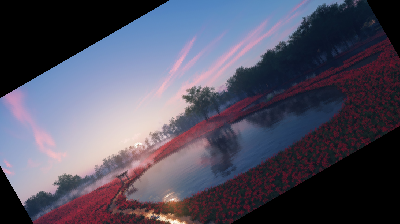

In [33]:
rotated

In [35]:
enhancer=ImageEnhance.Brightness(image)

In [38]:
brighter=enhancer.enhance(3)

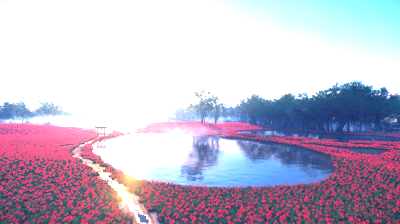

In [39]:
enhancer
brighter

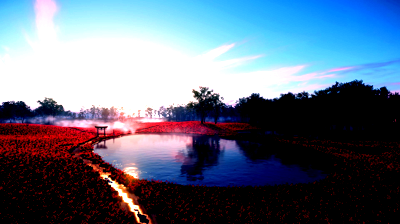

In [43]:
contrast=ImageEnhance.Contrast(image).enhance(2.7)

contrast

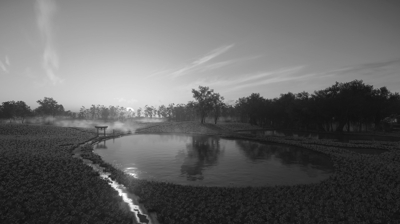

In [44]:
grayscale=ImageOps.grayscale(image)
grayscale

In [45]:
# Create a directory for augmented images
augmented_dir = "augmented_images"
#Creates the directory augmented_images
os.makedirs(augmented_dir, exist_ok=True)
 #Ensures no error is raised if the directory already exists.

# Augmentation functions
def augment_image(image, output_dir):
    # 1. Horizontal Flip
    # Flips the image horizontally (mirroring).
    flipped = ImageOps.mirror(image)
    #Saves the flipped image as flipped.jpeg in the output_dir
    flipped.save(os.path.join(output_dir, "flipped.jpeg"))

    # 2. Rotate
    rotated = image.rotate(30)
    #Rotates the image by 30 degrees (counterclockwise by default)
    rotated.save(os.path.join(output_dir, "rotated.jpeg"))

    # 3. Brightness Adjustment
    enhancer = ImageEnhance.Brightness(image)
    #Adjusts brightness by a factor of 1.5 (1.0 = original brightness).
    brighter = enhancer.enhance(1.5)
    brighter.save(os.path.join(output_dir, "brighter.jpeg"))

    # 4. Contrast Adjustment
    contrast = ImageEnhance.Contrast(image).enhance(2.0)
    #Doubles the image's contrast (2.0 = twice the original contrast).

    contrast.save(os.path.join(output_dir, "contrast.jpeg"))

    # 5. Grayscale
    grayscale = ImageOps.grayscale(image)
    grayscale.save(os.path.join(output_dir, "grayscale.jpeg"))

# Apply augmentations
augment_image(image, augmented_dir)
#Calls the augment_image function to apply all augmentations on the loaded image and save the results in the augmented_images directory.

# List the augmented files
print("Augmented images saved in:", augmented_dir)
print("Generated files:", os.listdir(augmented_dir))

Augmented images saved in: augmented_images
Generated files: ['rotated.jpeg', 'brighter.jpeg', 'flipped.jpeg', 'grayscale.jpeg', 'contrast.jpeg']


In [46]:
import matplotlib.pyplot as plt

In [47]:
augmented_images = os.listdir(augmented_dir)


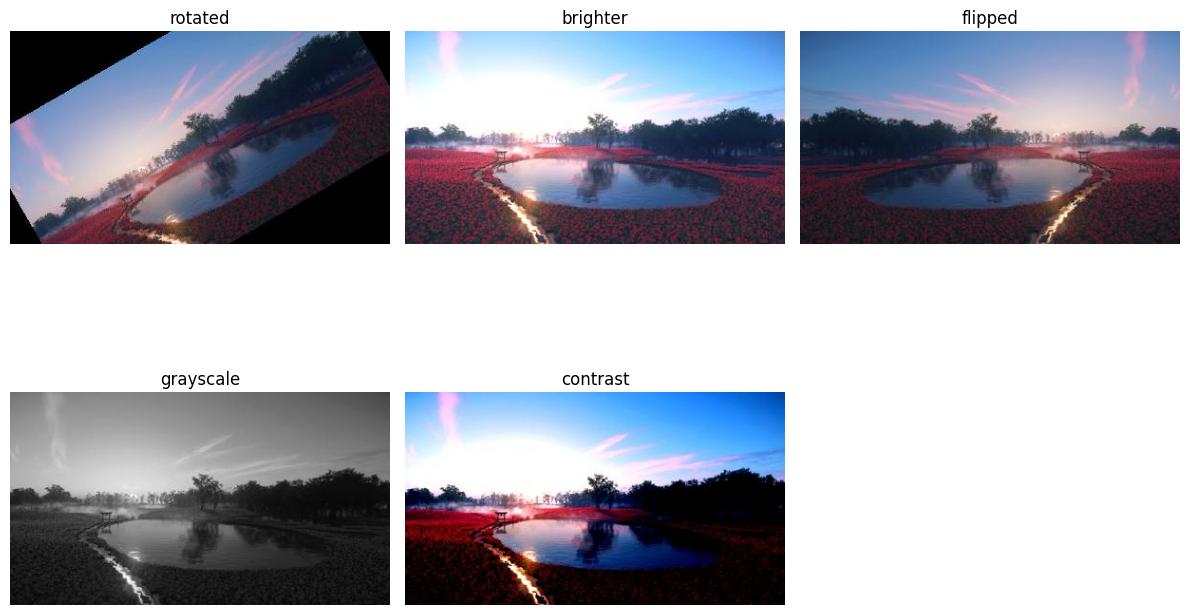

In [52]:
plt.figure(figsize=(12,8))
for i,img_file in  enumerate(augmented_images):
  img_path=os.path.join(augmented_dir,img_file)
  img=Image.open(img_path)
  plt.subplot(2,3,i+1)
  plt.imshow(img,cmap="gray" if img.mode=="L" else None)
  plt.title(img_file.split(".")[0])
  plt.axis("off")
plt.tight_layout()
plt.show()